# Рубежный контроль №1 

### Выполнил студент учебной группы РТ5-61Б Кулыгин Е. И
### Полученный вариант: 9
### Номер задачи: 2
Для заданного набора данных проведите обработку пропусков в данных для одного категориального и одного количественного признака. Какие способы обработки пропусков в данных для категориальных и количественных признаков Вы использовали? Какие признаки Вы будете использовать для дальнейшего построения моделей машинного обучения и почему?
### Полученный набор данных: 1 
Sklearn - Iris

## 1. Импорт необходимых библиотек

In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.impute import SimpleImputer

plt.style.use('ggplot')
sns.set_palette('Set2')
%matplotlib inline

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.3f}'.format)

print('Библиотеки успешно импортированы')

Библиотеки успешно импортированы


## 2. Загрузка данных и первичный анализ

In [31]:
# Загружаем датасет
iris = load_iris()

# Создаём DataFrame с целевой переменной
df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
df['species'] = iris.target

# Преобразуем числовые метки в названия видов
species_map = {0: 'setosa', 1: 'versicolor', 2: 'virginica'}
df['species'] = df['species'].map(species_map)

# Информация о данных
print('Размер датасета:', df.shape)
print('\nПервые 10 строк:')
display(df.head(10))
print('\nОписательная статистика:')
display(df.describe())

Размер датасета: (150, 5)

Первые 10 строк:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.100,3.500,1.400,0.200,setosa
1,4.900,3.000,1.400,0.200,setosa
2,4.700,3.200,1.300,0.200,setosa
3,4.600,3.100,1.500,0.200,setosa
4,5.000,3.600,1.400,0.200,setosa
5,5.400,3.900,1.700,0.400,setosa
6,4.600,3.400,1.400,0.300,setosa
7,5.000,3.400,1.500,0.200,setosa
8,4.400,2.900,1.400,0.200,setosa
9,4.900,3.100,1.500,0.100,setosa



Описательная статистика:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000,150.000,150.000,150.000
mean,5.843,3.057,3.758,1.199
std,0.828,0.436,1.765,0.762
min,4.300,2.000,1.000,0.100
25%,5.100,2.800,1.600,0.300
50%,5.800,3.000,4.350,1.300
75%,6.400,3.300,5.100,1.800
max,7.900,4.400,6.900,2.500


In [32]:
# Наличие пропусков в исходных данных
print('Количество пропусков в каждом столбце:')
print(df.isnull().sum())
print(f'\nОбщее количество пропусков: {df.isnull().sum().sum()}')
print('Типы данных:')
print(df.dtypes)

Количество пропусков в каждом столбце:
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
species              0
dtype: int64

Общее количество пропусков: 0
Типы данных:
sepal length (cm)    float64
sepal width (cm)     float64
petal length (cm)    float64
petal width (cm)     float64
species                  str
dtype: object


## 3. Создание категориального признака

Так как в датасете Iris все признаки количественные, а целевая переменная (species) не содержит пропусков, создадим искусственный категориальный признак на основе длины чашелистика (sepal length).

In [34]:
# Функция для категоризации длины чашелистика
def categorize_sepal_length(length):
    if length < 5.0:
        return 'короткий'
    elif length < 6.5:
        return 'средний'
    else:
        return 'длинный'

# Применяем категоризацию
df['sepal_length_category'] = df['sepal length (cm)'].apply(categorize_sepal_length)

print('Распределение категорий:')
print(df['sepal_length_category'].value_counts())
print(f'\nТип данных нового признака: {df["sepal_length_category"].dtype}')

Распределение категорий:
sepal_length_category
средний     93
длинный     35
короткий    22
Name: count, dtype: int64

Тип данных нового признака: str


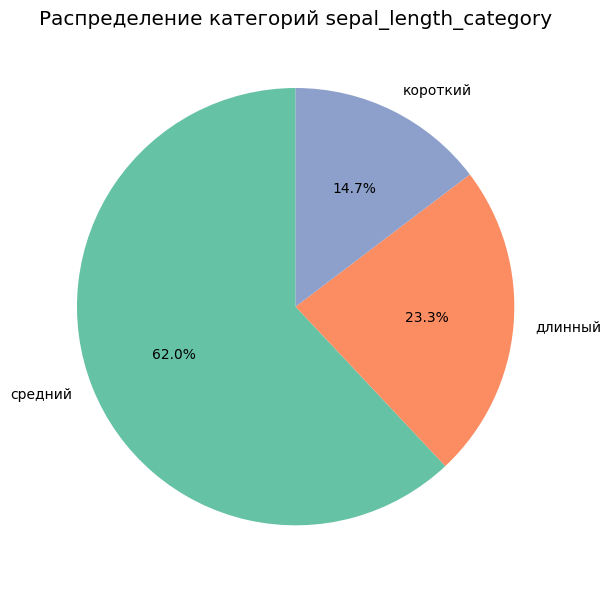

In [37]:
# Круговая диаграмма распределения категорий
fig, ax = plt.subplots(figsize=(8, 6))

category_counts = df['sepal_length_category'].value_counts()
ax.pie(category_counts.values, labels=category_counts.index, 
       autopct='%1.1f%%', startangle=90, colors=sns.color_palette('Set2'))
ax.set_title('Распределение категорий sepal_length_category')

plt.tight_layout()
plt.show()

## 4. Искусственное создание пропусков

Заменим 20% случайных значений на NaN в одном количественном признаке (petal length) и в созданном категориальном признаке (sepal_length_category).

In [38]:
# Фиксируем random seed для воспроизводимости результатов
np.random.seed(42)

# Создаём копию DataFrame для работы с пропусками
df_missing = df.copy()

# Пропуски в количественном признаке
n_missing_num = int(0.2 * len(df_missing))  # 20% от общего числа строк
missing_idx_num = np.random.choice(df_missing.index, n_missing_num, replace=False)
df_missing.loc[missing_idx_num, 'petal length (cm)'] = np.nan

# Пропуски в категориальном признаке 
n_missing_cat = int(0.2 * len(df_missing))
missing_idx_cat = np.random.choice(df_missing.index, n_missing_cat, replace=False)
df_missing.loc[missing_idx_cat, 'sepal_length_category'] = np.nan

print('Количество пропусков после внесения:')
print(f'petal length (cm): {df_missing["petal length (cm)"].isnull().sum()} '
      f'({df_missing["petal length (cm)"].isnull().sum() / len(df_missing) * 100:.1f}%)')
print(f'sepal_length_category: {df_missing["sepal_length_category"].isnull().sum()} '
      f'({df_missing["sepal_length_category"].isnull().sum() / len(df_missing) * 100:.1f}%)')

Количество пропусков после внесения:
petal length (cm): 30 (20.0%)
sepal_length_category: 30 (20.0%)


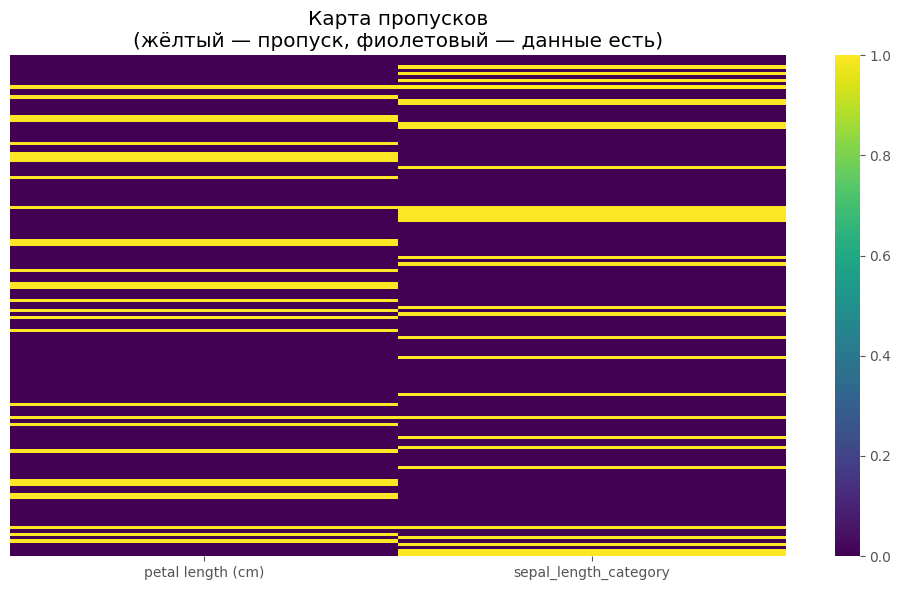

In [39]:
# Тепловая карта пропусков
fig, ax = plt.subplots(figsize=(10, 6))

sns.heatmap(df_missing[['petal length (cm)', 'sepal_length_category']].isnull(), 
            cbar=True, cmap='viridis', yticklabels=False, ax=ax)
ax.set_title('Карта пропусков\n(жёлтый — пропуск, фиолетовый — данные есть)')

plt.tight_layout()
plt.show()

In [40]:
# Посмотрим на строки с пропусками
print('Примеры строк с пропусками:')
display(df_missing[df_missing['petal length (cm)'].isnull() | 
                  df_missing['sepal_length_category'].isnull()].head(10))

Примеры строк с пропусками:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species,sepal_length_category
3,4.600,3.100,1.500,0.200,setosa,NaN
5,5.400,3.900,1.700,0.400,setosa,NaN
7,5.000,3.400,1.500,0.200,setosa,NaN
9,4.900,3.100,NaN,0.100,setosa,NaN
12,4.800,3.000,NaN,0.100,setosa,короткий
13,4.300,3.000,1.100,0.100,setosa,NaN
14,5.800,4.000,1.200,0.200,setosa,NaN
18,5.700,3.800,NaN,0.300,setosa,средний
19,5.100,3.800,NaN,0.300,setosa,средний
20,5.400,3.400,1.700,0.200,setosa,NaN


## 5. Обработка пропусков в количественном признаке

Рассмотрим два метода заполнения пропусков для количественного признака `petal length (cm)`:
- **Замена средним значением (mean imputation)**
- **Замена медианой (median imputation)**

In [42]:
# Оригинальная статистика до внесения пропусков
original_mean = df['petal length (cm)'].mean()
original_median = df['petal length (cm)'].median()
original_std = df['petal length (cm)'].std()

# Статистика с пропусками
missing_mean = df_missing['petal length (cm)'].mean()
missing_median = df_missing['petal length (cm)'].median()

print('Сравнение статистик')
print(f'{"":20} {"Оригинал":>12} {"С пропусками":>15}')
print(f'{"Среднее":20} {original_mean:12.4f} {missing_mean:15.4f}')
print(f'{"Медиана":20} {original_median:12.4f} {missing_median:15.4f}')
print(f'{"Стд. откл.":20} {original_std:12.4f} {df_missing["petal length (cm)"].std():15.4f}')

Сравнение статистик
                         Оригинал    С пропусками
Среднее                    3.7580          3.7267
Медиана                    4.3500          4.2500
Стд. откл.                 1.7653          1.7523


In [45]:
# Метод 1: Замена средним значением
df_mean_imputed = df_missing.copy()
imputer_mean = SimpleImputer(strategy='mean')
df_mean_imputed['petal length (cm)'] = imputer_mean.fit_transform(
    df_mean_imputed[['petal length (cm)']]
)

# Метод 2: Замена медианой
df_median_imputed = df_missing.copy()
imputer_median = SimpleImputer(strategy='median')
df_median_imputed['petal length (cm)'] = imputer_median.fit_transform(
    df_median_imputed[['petal length (cm)']]
)

# Сравнение результатов
print('Сравнение методов заполнения (petal length)')
print(f'{"":25} {"Оригинал":>10} {"Mean":>12} {"Median":>12}')
print(f'{"Среднее":25} {df["petal length (cm)"].mean():10.4f} '
      f'{df_mean_imputed["petal length (cm)"].mean():12.4f} '
      f'{df_median_imputed["petal length (cm)"].mean():12.4f}')
print(f'{"Медиана":25} {df["petal length (cm)"].median():10.4f} '
      f'{df_mean_imputed["petal length (cm)"].median():12.4f} '
      f'{df_median_imputed["petal length (cm)"].median():12.4f}')
print(f'{"Стд. откл.":25} {df["petal length (cm)"].std():10.4f} '
      f'{df_mean_imputed["petal length (cm)"].std():12.4f} '
      f'{df_median_imputed["petal length (cm)"].std():12.4f}')

Сравнение методов заполнения (petal length)
                            Оригинал         Mean       Median
Среднее                       3.7580       3.7267       3.8313
Медиана                       4.3500       3.7267       4.2500
Стд. откл.                    1.7653       1.5660       1.5801


**Вывод по количественному признаку:** замена средним сохраняет среднее значение, но уменьшает дисперсию. Замена медианой лучше работает при наличии выбросов. В нашем случае оба метода дают схожие результаты, так как данные распределены относительно равномерно.

## 6. Обработка пропусков в категориальном признаке

Для категориального признака `sepal_length_category` используем метод **замены модой** (самым частым значением).

In [46]:
# Распределение категорий
print('Распределение категорий (оригинал):')
print(df['sepal_length_category'].value_counts())
print(f'\nМода (самое частое значение): {df["sepal_length_category"].mode()[0]}')
print(f'Количество пропусков: {df_missing["sepal_length_category"].isnull().sum()}')

Распределение категорий (оригинал):
sepal_length_category
средний     93
длинный     35
короткий    22
Name: count, dtype: int64

Мода (самое частое значение): средний
Количество пропусков: 30


In [49]:
# Заполняем пропуски модой
df_filled = df_mean_imputed.copy()  # берём версию с mean imputation для числового

# Для категориального признака используем strategy='most_frequent'
imputer_cat = SimpleImputer(strategy='most_frequent')
df_filled['sepal_length_category'] = imputer_cat.fit_transform(
    df_filled[['sepal_length_category']]
).ravel()  

print(f'petal length (cm): {df_filled["petal length (cm)"].isnull().sum()} пропусков')
print(f'sepal_length_category: {df_filled["sepal_length_category"].isnull().sum()} пропусков')
print(f'\nОбщее количество пропусков: {df_filled.isnull().sum().sum()}')

petal length (cm): 0 пропусков
sepal_length_category: 0 пропусков

Общее количество пропусков: 0


**Вывод по категориальному признаку:** замена модой — логичный и простой метод для категориальных данных. Категория с наибольшей частотой («средний» в нашем случае) используется для заполнения пропусков.

## 7. Финальная проверка обработанных данных

In [50]:
print(f'\nРазмер данных: {df_filled.shape}')
print(f'Общее количество пропусков: {df_filled.isnull().sum().sum()}')
print('\nИнформация о данных:')
df_filled.info()
print('\nПервые 10 строк обработанных данных:')
display(df_filled.head(10))


Размер данных: (150, 6)
Общее количество пропусков: 0

Информация о данных:
<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   sepal length (cm)      150 non-null    float64
 1   sepal width (cm)       150 non-null    float64
 2   petal length (cm)      150 non-null    float64
 3   petal width (cm)       150 non-null    float64
 4   species                150 non-null    str    
 5   sepal_length_category  150 non-null    str    
dtypes: float64(4), str(2)
memory usage: 7.2 KB

Первые 10 строк обработанных данных:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species,sepal_length_category
0,5.100,3.500,1.400,0.200,setosa,средний
1,4.900,3.000,1.400,0.200,setosa,короткий
2,4.700,3.200,1.300,0.200,setosa,короткий
3,4.600,3.100,1.500,0.200,setosa,средний
4,5.000,3.600,1.400,0.200,setosa,средний
5,5.400,3.900,1.700,0.400,setosa,средний
6,4.600,3.400,1.400,0.300,setosa,короткий
7,5.000,3.400,1.500,0.200,setosa,средний
8,4.400,2.900,1.400,0.200,setosa,короткий
9,4.900,3.100,3.727,0.100,setosa,средний


## 8. Построение Jointplot

Jointplot — график, объединяющий диаграмму рассеяния с гистограммами распределений каждой переменной по краям. Построим его для пары признаков: `sepal length (cm)` и `petal length (cm)`.

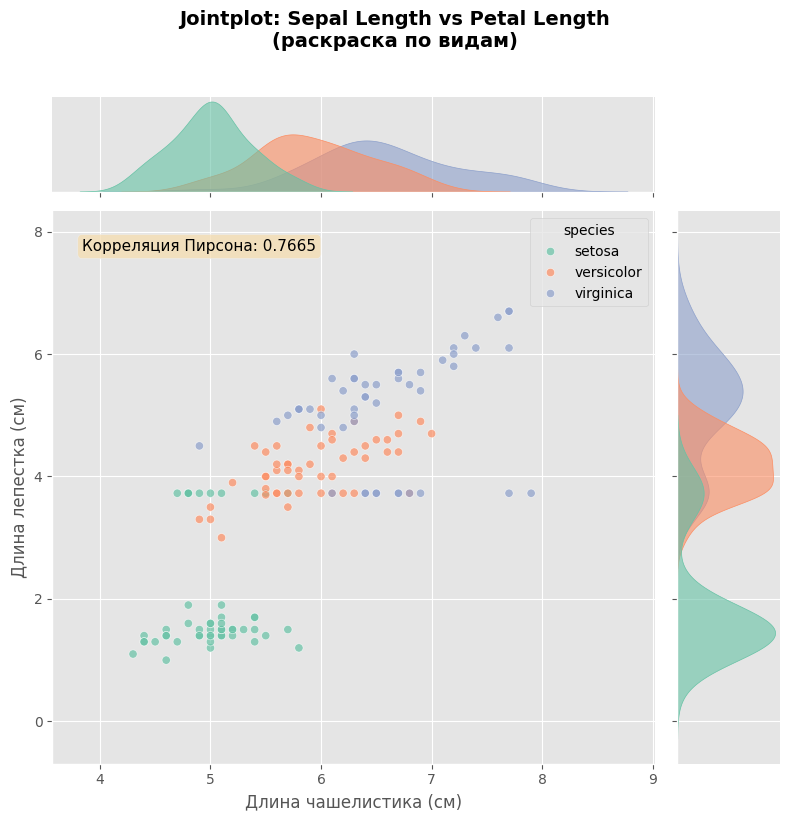

In [17]:
# === Jointplot с раскраской по видам ирисов ===
g = sns.jointplot(
    data=df_filled,
    x='sepal length (cm)',
    y='petal length (cm)',
    hue='species',          # раскрашиваем точки по видам
    kind='scatter',         # тип графика: scatter (точки)
    height=8,               # размер графика
    alpha=0.7,              # прозрачность точек
    # Убираем marginal_kws с bins, так как kdeplot его не поддерживает
    marginal_kws=dict(fill=True, alpha=0.6, common_norm=False)
)

# Настройка подписей
g.set_axis_labels('Длина чашелистика (см)', 'Длина лепестка (см)', fontsize=12)
g.fig.suptitle('Jointplot: Sepal Length vs Petal Length\n(раскраска по видам)', 
               y=1.02, fontsize=14, fontweight='bold')

# Добавляем коэффициент корреляции
corr = df_filled['sepal length (cm)'].corr(df_filled['petal length (cm)'])
g.ax_joint.text(0.05, 0.95, f'Корреляция Пирсона: {corr:.4f}', 
                transform=g.ax_joint.transAxes, fontsize=11,
                verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

plt.tight_layout()
plt.show()

## 9. Ответы на контрольные вопросы

### Вопрос 1: Какие способы обработки пропусков в данных для категориальных и количественных признаков Вы использовали?

**Для количественного признака (`petal length`):**
1. **Замена средним значением (mean imputation)** — простой и быстрый метод, заменяет все пропуски на среднее арифметическое оставшихся значений. Метод хорошо работает при нормальном распределении данных, но может искажать дисперсию.
2. **Замена медианой (median imputation)** — более устойчив к выбросам, так как медиана менее чувствительна к экстремальным значениям. Рекомендуется при наличии выбросов в данных.

**Для категориального признака (`sepal_length_category`):**
1. **Замена модой (most frequent / mode imputation)** — стандартный подход для категориальных данных. Пропуски заменяются категорией, которая встречается чаще всего. Это логично, так как мода представляет наиболее вероятное значение категории.

---

### Вопрос 2: Какие признаки Вы будете использовать для дальнейшего построения моделей машинного обучения и почему?

Для построения моделей я буду использовать **все 4 исходных количественных признака**:
- `sepal length (cm)` — длина чашелистика
- `sepal width (cm)` — ширина чашелистика
- `petal length (cm)` — длина лепестка
- `petal width (cm)` — ширина лепестка


**`sepal_length_category` - не подходит:**
- Этот признак создан искусственно из `sepal length (cm)` путём дискретизации.
- Он содержит ту же информацию, но с потерями (огрубление).